# Structure function and pair correlation

I developed my structure-function and pair-correlation codes for analyzing simulated microstructures. Here I present the calculation in small tested steps. This notebook uses NumPy’s Fourier convention and explicitly checks its normalization. It does not simulate microstructural evolution.

**Using my code.** I permit free noncommercial teaching, learning and demonstrations with acknowledgment. Research (including academic research) and commercial use require my explicit written permission. Earlier MIT and GPL releases retain their existing permissions. Read the [code-use terms](https://saswataiith.github.io/files/CODE-USE-TERMS.txt). Request permission at saswata_at_msme.iith.ac.in. These terms apply to code; teaching text and figures have separate terms.


## 1. Start with a field whose correlation is known

I choose a cosine composition wave on a periodic 16 by 16 grid. The composition c is dimensionless. Grid spacings dx and dy are one dimensionless length unit. Rows index x and columns index y, following the saved simulation arrays. The wave varies in x and is constant in y, so I can check the full directional result before averaging over directions.

In [1]:
import numpy as np
n = 16
dx = dy = 1.0
x = np.arange(n) * dx
composition = 0.5 + 0.2 * np.cos(2 * np.pi * x[:, None] / (n * dx)) * np.ones((1, n))
assert composition.shape == (n, n)
assert abs(composition.mean() - 0.5) < 1e-12
print("Mean composition:", composition.mean())

Mean composition: 0.5


## 2. Remove the mean and calculate the variance

I use the fluctuation δc = c minus the measured mean of this field. Its variance is the mean of δc². Removing the actual mean avoids a residual zero mode when a nominal alloy composition differs from the saved field mean.

In [2]:
fluctuation = composition - composition.mean()
variance = np.mean(fluctuation**2)
assert abs(fluctuation.mean()) < 1e-12
assert abs(variance - 0.02) < 1e-12
print("Composition variance:", variance)

Composition variance: 0.020000000000000004


## 3. Calculate the structure function

I define F as the unnormalized forward discrete Fourier transform of δc and N as the total number of grid cells. The structure function is S = |F|²/N. Its units are squared composition units under this discrete convention; here they are dimensionless. It is nonnegative. Its sum divided by N equals the real-space variance. This check detects normalization errors.

In [3]:
cells = composition.size
transform = np.fft.fft2(fluctuation)
structure = np.abs(transform)**2 / cells
assert np.all(structure >= 0)
assert abs(structure[0, 0]) < 1e-12
assert abs(structure.sum() / cells - variance) < 1e-12
print("Parseval check:", structure.sum() / cells, variance)

Parseval check: 0.020000000000000004 0.020000000000000004


## 4. Invert the spectrum to obtain pair correlation

The unnormalized covariance C at displacement r is the spatial average of δc(x)δc(x+r). With NumPy’s normalized inverse transform, C = ifft2(S).real. I define the normalized correlation ρ = C/C(0). The origin must be one. A constant field has zero variance, so its normalized correlation is undefined; I reject it rather than divide by zero.

In [4]:
def correlation_from_field(field):
    deviation = field - field.mean()
    variance = np.mean(deviation**2)
    if variance == 0:
        raise ValueError("A constant field has undefined normalized correlation.")
    structure = np.abs(np.fft.fft2(deviation))**2 / field.size
    covariance = np.fft.ifft2(structure).real
    return structure, covariance, covariance / variance

structure, covariance, correlation = correlation_from_field(composition)
assert abs(covariance[0, 0] - variance) < 1e-12
assert abs(correlation[0, 0] - 1) < 1e-12
try:
    correlation_from_field(np.ones((4, 4)))
except ValueError:
    print("Constant-field check passed.")
else:
    raise AssertionError("The constant field must be rejected.")

Constant-field check passed.


## 5. Check every displacement by a direct sum

I now calculate the same covariance without using a Fourier transform. np.roll implements periodic displacements. This direct calculation is slow for large grids, but useful as an independent check on a small grid. The cosine field should give ρ(r_x,r_y) = cos(2π r_x/L_x), independent of r_y.

In [5]:
direct = np.zeros_like(composition)
for row in range(n):
    for column in range(n):
        shifted = np.roll(fluctuation, (row, column), axis=(0, 1))
        direct[row, column] = np.mean(fluctuation * shifted)
expected = np.cos(2 * np.pi * np.arange(n)[:, None] / n) * np.ones((1, n))
assert np.max(np.abs(direct - covariance)) < 1e-12
assert np.max(np.abs(correlation - expected)) < 1e-12
print("Direct-sum maximum error:", np.max(np.abs(direct - covariance)))

Direct-sum maximum error: 3.469446951953614e-18


## 6. Average by radius only after checking the directional data

For the correlation I bin by real-space displacement radius r, in length units, using minimum-image displacements. For the structure function I bin by wave-number magnitude k, in inverse-length units. They need separate radii and bin widths. Radial averaging discards direction information and can conceal anisotropy. Empty bins are omitted rather than divided by zero.

In [6]:
def radial_average(values, radii, bin_width):
    bins = np.floor(radii / bin_width + 0.5).astype(int)
    occupied_bins = np.unique(bins)
    centers = occupied_bins * bin_width
    means = np.array([values[bins == index].mean() for index in occupied_bins])
    counts = np.array([np.count_nonzero(bins == index) for index in occupied_bins])
    return centers, means, counts

rx = np.fft.fftfreq(n) * n * dx
ry = np.fft.fftfreq(n) * n * dy
real_radius = np.sqrt(rx[:, None]**2 + ry[None, :]**2)
kx = 2 * np.pi * np.fft.fftfreq(n, d=dx)
ky = 2 * np.pi * np.fft.fftfreq(n, d=dy)
wave_radius = np.sqrt(kx[:, None]**2 + ky[None, :]**2)
r, radial_correlation, counts = radial_average(correlation, real_radius, min(dx, dy))
k, radial_structure, mode_counts = radial_average(structure, wave_radius, min(2*np.pi/(n*dx), 2*np.pi/(n*dy)))
assert counts.sum() == cells and mode_counts.sum() == cells
assert radial_correlation[0] == correlation[0, 0]
print("Correlation radii:", r)
print("Wave-number magnitudes:", k)

Correlation radii: [ 0.  1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11.]
Wave-number magnitudes: [0.         0.39269908 0.78539816 1.17809725 1.57079633 1.96349541
 2.35619449 2.74889357 3.14159265 3.53429174 3.92699082 4.3196899 ]


## 7. Report a first zero only if one is present

A first zero is one possible characteristic length. I find the first positive-to-nonpositive crossing and linearly interpolate between the sampled values. If no such crossing is present in the sampled range, I return None. This is not automatically a particle radius, and it is not a connectivity measurement. For the directional cosine test, the first zero is at one quarter of the wavelength.

Directional first zero: 4.0
Radial first zero: 5.991324989519286


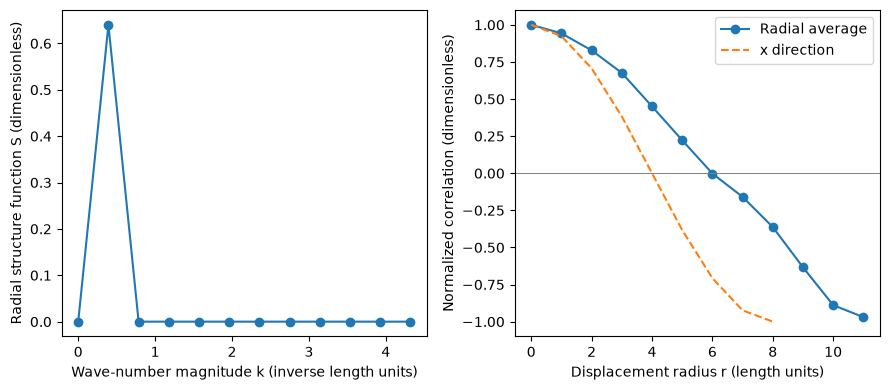

In [7]:
def first_zero(distances, values):
    for index in range(1, len(values)):
        if values[index - 1] > 0 and values[index] <= 0:
            fraction = values[index - 1] / (values[index - 1] - values[index])
            return distances[index - 1] + fraction * (distances[index] - distances[index - 1])
    return None

directional_zero = first_zero(x[:n//2+1], correlation[:n//2+1, 0])
assert abs(directional_zero - n * dx / 4) < 1e-12
assert first_zero(np.arange(3), np.ones(3)) is None
print("Directional first zero:", directional_zero)
print("Radial first zero:", first_zero(r, radial_correlation))

import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
axes[0].plot(k, radial_structure, "o-")
axes[0].set_xlabel("Wave-number magnitude k (inverse length units)")
axes[0].set_ylabel("Radial structure function S (dimensionless)")
axes[1].plot(r, radial_correlation, "o-", label="Radial average")
axes[1].plot(x[:n//2+1], correlation[:n//2+1, 0], "--", label="x direction")
axes[1].axhline(0, color="gray", linewidth=0.7)
axes[1].set_xlabel("Displacement radius r (length units)")
axes[1].set_ylabel("Normalized correlation (dimensionless)")
axes[1].legend()
fig.tight_layout()
plt.show()